In [19]:
!pip install tabulate

     ---------------------------------------- 0.0/40.8 kB ? eta -:--:--
     ---------- ----------------------------- 10.2/40.8 kB ? eta -:--:--
     ------------------- ------------------ 20.5/40.8 kB 217.9 kB/s eta 0:00:01
     -------------------------------------- 40.8/40.8 kB 244.3 kB/s eta 0:00:00



[notice] A new release of pip is available: 24.0 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [1]:
!pip install pandas numpy matplotlib seaborn openpyxl


[notice] A new release of pip is available: 24.0 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


# Oxford GARI 2025 — Nepal Global Positioning Analysis

**Source:** Oxford Insights, *Government AI Readiness Index 2025* (195 countries, 
69 indicators, 14 dimensions, 6 pillars). Data file: `2025GovernmentAIReadinessIndexdata.xlsx`, 
sheet `Dimensions-Pillars`.

**Purpose:** Establish Nepal's validated global and regional position across all six 
GARI pillars and fourteen subdimensions, using the full country sample rather than a 
hand-picked comparison set. Peer groups below are selected by explicit, reproducible 
rules (see Section 2) so results are defensible to a reviewer.

**Outputs:** publication-ready tables (`../data/processed/`) and figures 
(`../outputs/figures/`, 300 dpi, PNG) for direct use in the manuscript.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from pathlib import Path
from scipy import stats

### Setup

In [3]:
RAW_DIR = Path("../data/raw")
PROCESSED_DIR = Path("../data/processed")
FIG_DIR = Path("../outputs/figures")
PROCESSED_DIR.mkdir(parents=True, exist_ok=True)
FIG_DIR.mkdir(parents=True, exist_ok=True)

In [4]:
OXFORD_FILE = RAW_DIR / "2025GovernmentAIReadinessIndexdata.xlsx"

In [5]:
plt.rcParams.update({
    "figure.dpi": 120,
    "savefig.dpi": 300,
    "font.size": 11,
    "font.family": "sans-serif",
    "axes.titlesize": 13,
    "axes.titleweight": "bold",
    "axes.labelsize": 11,
    "axes.edgecolor": "#333333",
    "axes.grid": True,
    "grid.alpha": 0.25,
    "figure.facecolor": "white",
    "savefig.facecolor": "white",
})
sns.set_style("whitegrid")

NEPAL = "Nepal"

## 1. Load full 195-country dataset

Single source sheet (`Dimensions-Pillars`) already contains both pillar-level (6) 
and subdimension-level (14) scores for all 195 countries — no merge needed.

In [7]:
xl = pd.ExcelFile(OXFORD_FILE)
df = xl.parse("Dimensions-Pillars", header=1)
df = df.drop(columns=[c for c in df.columns if "Unnamed" in str(c)])
df = df.dropna(subset=["Country"]).reset_index(drop=True)
df["Ranking"] = df["Ranking"].astype(int)

In [8]:
PILLARS = [
    "Policy Capacity", "AI Infrastructure", "Governance",
    "Public Sector Adoption", "Development & Diffusion", "Resilience",
]
SUBDIMS = [
    "Policy vision", "Policy commitment", "Compute capacity",
    "Enabling technical infrastructure", "Data quality", "Governance principles",
    "Regulatory compliance", "Government digital policy", "e-Government delivery",
    "Human capital", "AI sector maturity", "AI technology diffusion",
    "Societal transition", "Safety and security",
]

In [9]:
assert NEPAL in df.Country.values, "Nepal not found — check country naming in source file"
print(f"Loaded {len(df)} countries, {len(PILLARS)} pillars, {len(SUBDIMS)} subdimensions.")
df.head(3)

Loaded 195 countries, 6 pillars, 14 subdimensions.


,Ranking,Country,Total Score,Policy Capacity,AI Infrastructure,Governance,Public Sector Adoption,Development & Diffusion,Resilience,Policy vision,...,Data quality,Governance principles,Regulatory compliance,Government digital policy,e-Government delivery,Human capital,AI sector maturity,AI technology diffusion,Societal transition,Safety and security
0,188,Afghanistan,15.72,0.0,19.27,11.25,26.80,11.76,22.56,0.0,...,16.95,2.5,20.00,0.00,53.59,18.41,4.85,14.33,22.13,23.00
1,85,Albania,43.44,23.0,51.21,51.67,68.95,24.35,41.60,20.0,...,79.79,50.0,53.33,51.03,86.86,21.23,14.18,41.04,49.87,33.33
2,89,Algeria,42.05,65.5,43.12,59.00,26.42,33.86,34.44,70.0,...,61.37,48.0,70.00,23.80,29.05,33.86,20.10,52.21,35.55,33.33


## 2. Peer group definitions (reproducible, not hand-picked)

- **Global Top 10** — highest Total Score, for context on the frontier.
- **Asia Neighbors** — fixed geographic list (South Asia + immediate region).
- **Structural Peers** — the 6 countries with the closest Total Score to Nepal's, 
  computed algorithmically (nearest-neighbor on Total Score, Nepal excluded). 
  This replaces any manually chosen "similar country" list.

In [10]:
GLOBAL_TOP10 = df.nsmallest(10, "Ranking")["Country"].tolist()
ASIA_NEIGHBORS = [
    "Nepal", "India", "China", "Pakistan", "Bangladesh",
    "Sri Lanka", "Bhutan", "Myanmar", "Afghanistan", "Maldives",
]
nepal_score = df.loc[df.Country == NEPAL, "Total Score"].iloc[0]
df["_dist_to_nepal"] = (df["Total Score"] - nepal_score).abs()
STRUCTURAL_PEERS = (
    df[df.Country != NEPAL]
    .nsmallest(6, "_dist_to_nepal")["Country"]
    .tolist()
)
df = df.drop(columns="_dist_to_nepal")
print("Global Top 10:      ", GLOBAL_TOP10)
print("Asia Neighbors:      ", ASIA_NEIGHBORS)
print("Structural Peers:    ", STRUCTURAL_PEERS, f"(nearest Total Score to Nepal's {nepal_score})")

Global Top 10:       ['United States of America', 'France', 'United Kingdom of Great Britain and Northern Ireland', 'Netherlands', 'Republic of Korea', 'Germany', 'Singapore', 'China', 'Australia', 'Norway']
Asia Neighbors:       ['Nepal', 'India', 'China', 'Pakistan', 'Bangladesh', 'Sri Lanka', 'Bhutan', 'Myanmar', 'Afghanistan', 'Maldives']
Structural Peers:     ['Monaco', 'El Salvador', 'Armenia', 'Panama', 'Bhutan', 'North Macedonia'] (nearest Total Score to Nepal's 38.5)


## 3. Nepal scorecard — publication table

Full pillar + subdimension breakdown with global rank and percentile for each metric.

In [12]:
def percentile_and_rank(series: pd.Series, value: float) -> tuple[float, int]:
    """Percentile (higher = better) and rank-from-bottom out of n."""
    pct = stats.percentileofscore(series.dropna(), value)
    rank_from_bottom = int((series.dropna() < value).sum()) + 1
    return round(pct, 1), rank_from_bottom

rows = []
nepal_row = df[df.Country == NEPAL].iloc[0]
for metric in ["Total Score"] + PILLARS + SUBDIMS:
    pct, rank_bottom = percentile_and_rank(df[metric], nepal_row[metric])
    rows.append({
        "Metric": metric,
        "Nepal score": round(nepal_row[metric], 2),
        "Global percentile": pct,
        "N countries scoring lower": rank_bottom - 1,
        "N total": df[metric].notna().sum(),
    })

nepal_scorecard = pd.DataFrame(rows)
nepal_scorecard.to_csv(PROCESSED_DIR / "nepal_scorecard_full_sample.csv", index=False)
nepal_scorecard

,Metric,Nepal score,Global percentile,N countries scoring lower,N total
0,Total Score,38.50,46.2,89,195
1,Policy Capacity,49.50,57.2,110,195
2,AI Infrastructure,38.05,38.5,74,195
3,Governance,57.24,54.4,105,195
4,Public Sector Adoption,32.88,36.9,71,195
5,Development & Diffusion,22.50,39.0,75,195
6,Resilience,48.94,66.2,128,195
7,Policy vision,30.00,42.8,71,195
8,Policy commitment,62.50,63.3,114,195
9,Compute capacity,6.90,60.3,116,195


## 4. Figure 1 — Pillar comparison: Nepal vs. Global Top 10 vs. Asia Neighbors vs. Structural Peers

Grouped bar chart, one panel per pillar group, Nepal highlighted.

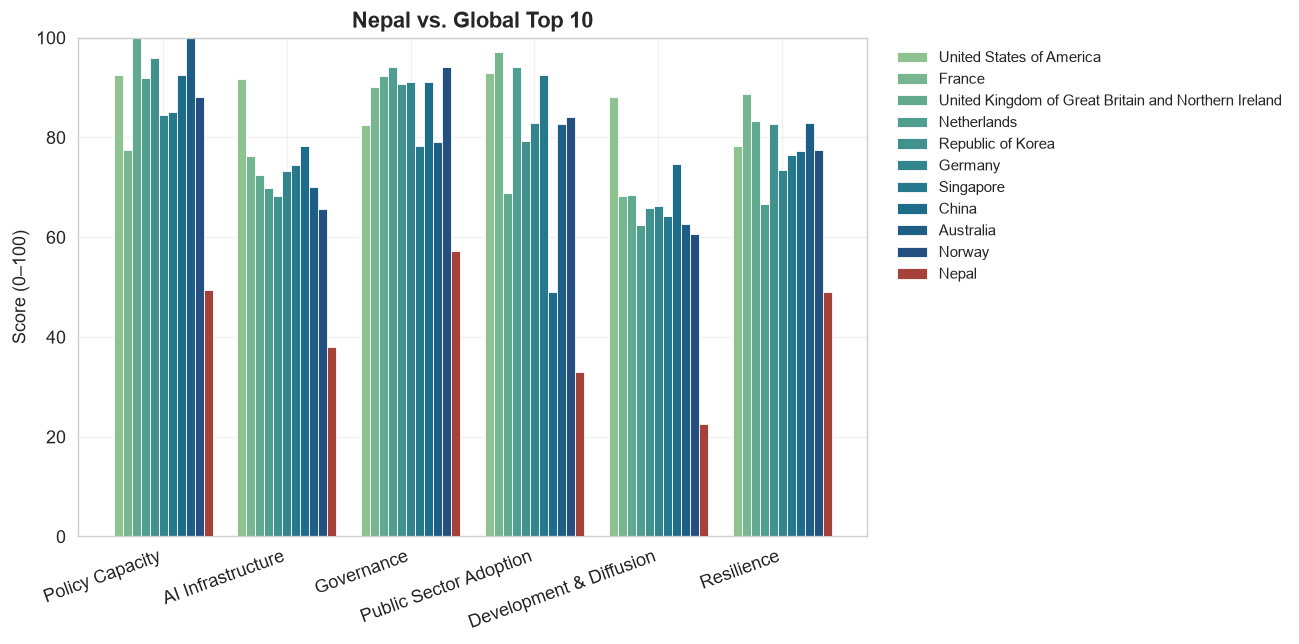

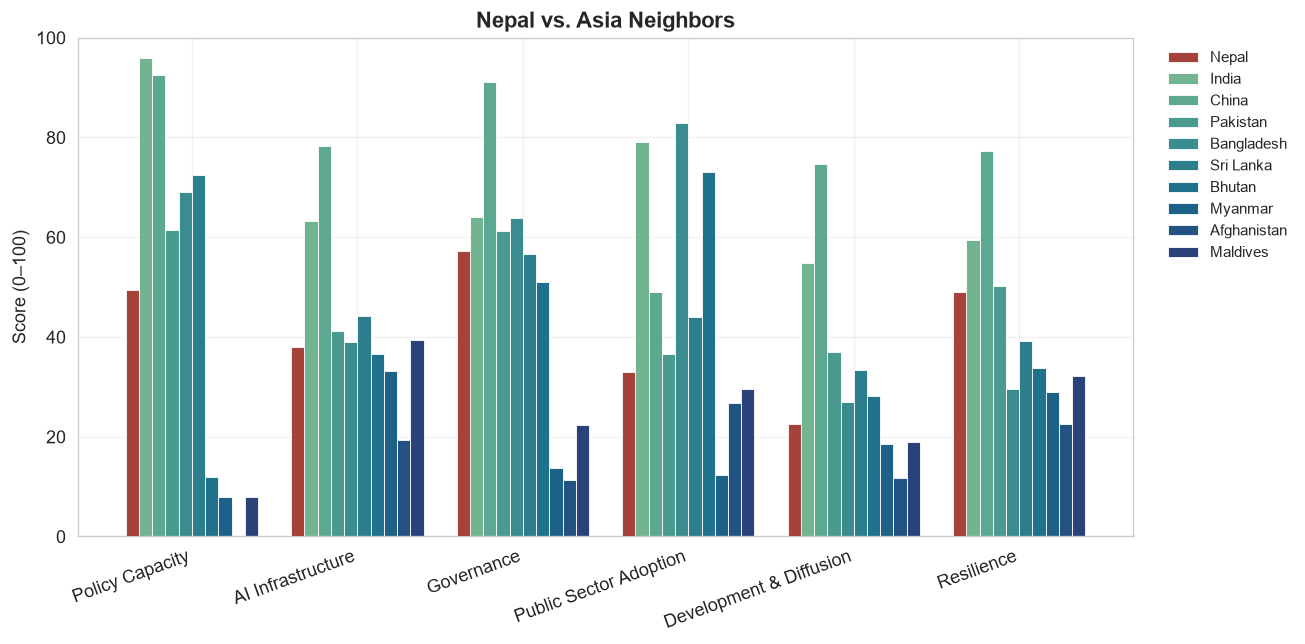

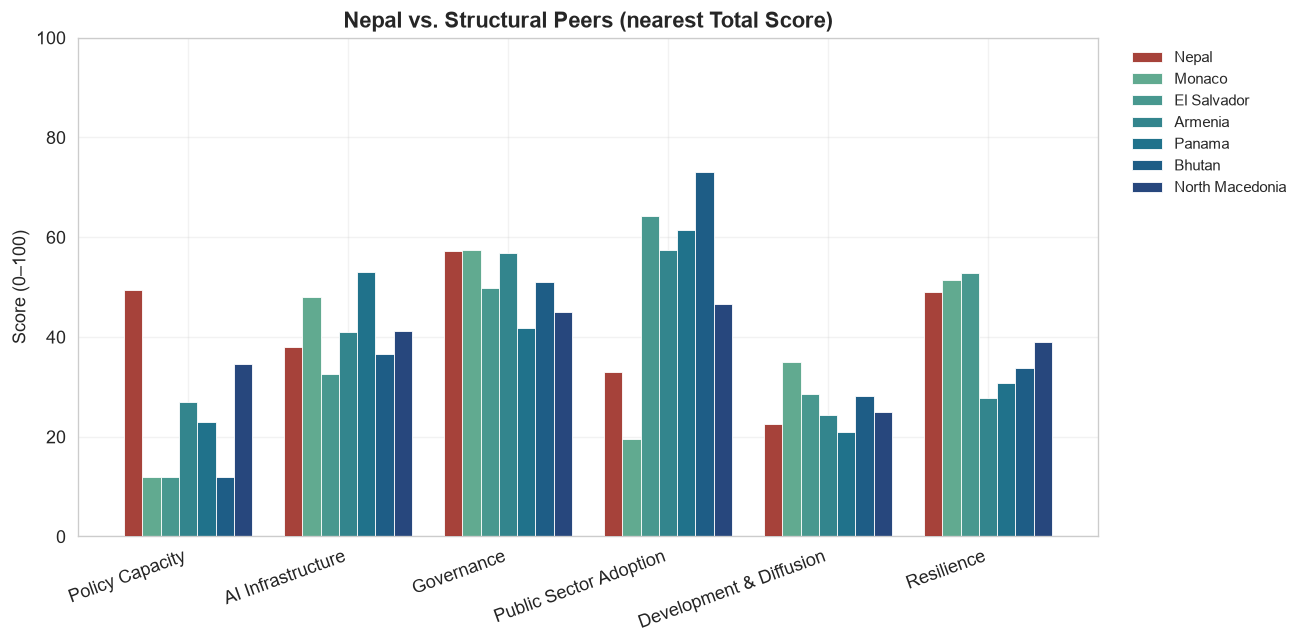

In [13]:
def plot_group_comparison(countries, title, filename, highlight=NEPAL, palette="crest"):
    subset = df[df.Country.isin(countries)].set_index("Country").loc[
        [c for c in countries if c in df.Country.values]
    ]
    fig, ax = plt.subplots(figsize=(11, 5.5))
    x = np.arange(len(PILLARS))
    width = 0.8 / len(subset)
    colors = sns.color_palette(palette, len(subset))

    for i, (country, row) in enumerate(subset.iterrows()):
        vals = [row[p] for p in PILLARS]
        bar_color = "#A6423A" if country == highlight else colors[i]
        ax.bar(x + i * width, vals, width, label=country, color=bar_color,
               edgecolor="white", linewidth=0.5,
               zorder=3 if country == highlight else 2)

    ax.set_xticks(x + width * (len(subset) - 1) / 2)
    ax.set_xticklabels(PILLARS, rotation=20, ha="right")
    ax.set_ylabel("Score (0–100)")
    ax.set_title(title)
    ax.legend(bbox_to_anchor=(1.02, 1), loc="upper left", frameon=False, fontsize=9)
    ax.set_ylim(0, 100)
    fig.tight_layout()
    fig.savefig(FIG_DIR / filename, bbox_inches="tight")
    plt.show()

plot_group_comparison(GLOBAL_TOP10 + [NEPAL], "Nepal vs. Global Top 10", "fig1a_top10_vs_nepal.png")
plot_group_comparison(ASIA_NEIGHBORS, "Nepal vs. Asia Neighbors", "fig1b_asia_neighbors.png")
plot_group_comparison([NEPAL] + STRUCTURAL_PEERS, "Nepal vs. Structural Peers (nearest Total Score)", "fig1c_structural_peers.png")

## 5. Figure 2 — Subdimension heatmap

Nepal + all three peer groups (deduplicated), 14 subdimensions. This is the figure 
that shows *where* the gaps concentrate (e.g. Government digital policy, AI sector 
maturity) rather than just the six aggregated pillar scores.

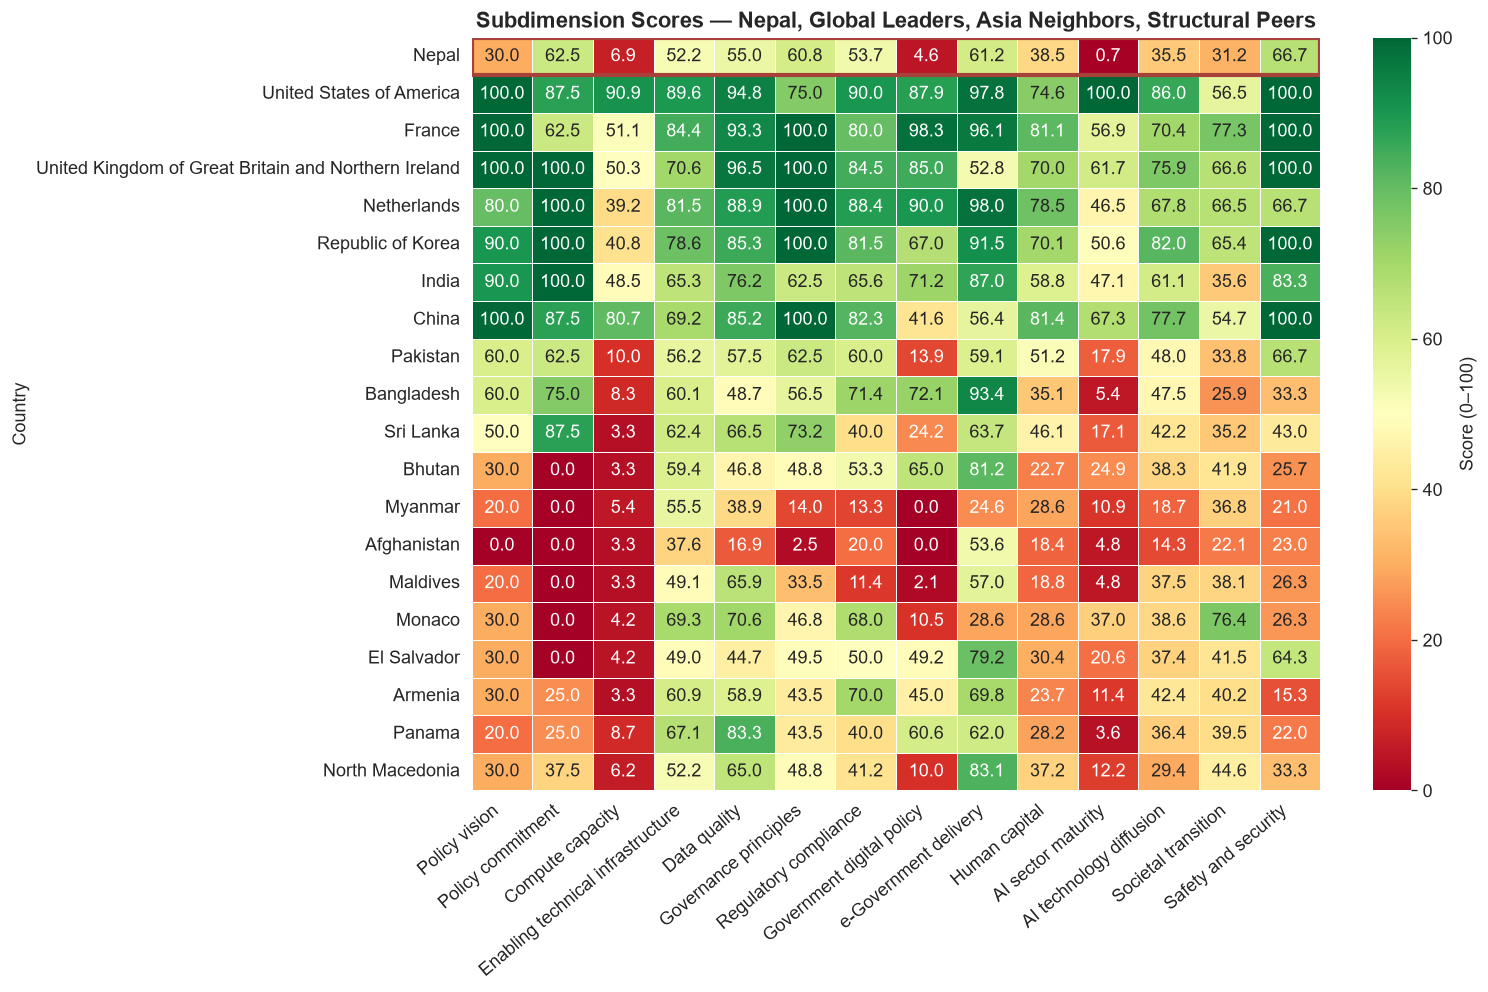

In [14]:
heatmap_countries = list(dict.fromkeys(
    [NEPAL] + GLOBAL_TOP10[:5] + ASIA_NEIGHBORS + STRUCTURAL_PEERS
))
heat_df = df[df.Country.isin(heatmap_countries)].set_index("Country")[SUBDIMS]
heat_df = heat_df.loc[[c for c in heatmap_countries if c in heat_df.index]]

fig, ax = plt.subplots(figsize=(13, max(6, 0.42 * len(heat_df))))
sns.heatmap(
    heat_df, annot=True, fmt=".1f", cmap="RdYlGn", vmin=0, vmax=100,
    linewidths=0.6, linecolor="white", cbar_kws={"label": "Score (0–100)"}, ax=ax
)
# Highlight Nepal's row
if NEPAL in heat_df.index:
    idx = heat_df.index.get_loc(NEPAL)
    ax.add_patch(plt.Rectangle((0, idx), len(SUBDIMS), 1, fill=False, edgecolor="#A6423A", lw=2.5))

ax.set_title("Subdimension Scores — Nepal, Global Leaders, Asia Neighbors, Structural Peers")
plt.xticks(rotation=40, ha="right")
fig.tight_layout()
fig.savefig(FIG_DIR / "fig2_subdimension_heatmap.png", bbox_inches="tight")
plt.show()

## 6. Figure 3 — Global distribution with Nepal marked

For the metrics that matter most to the paper's argument: Total Score, Compute 
capacity, Government digital policy, AI sector maturity. Shows Nepal's position 
against the full 195-country distribution, not just a table of numbers.

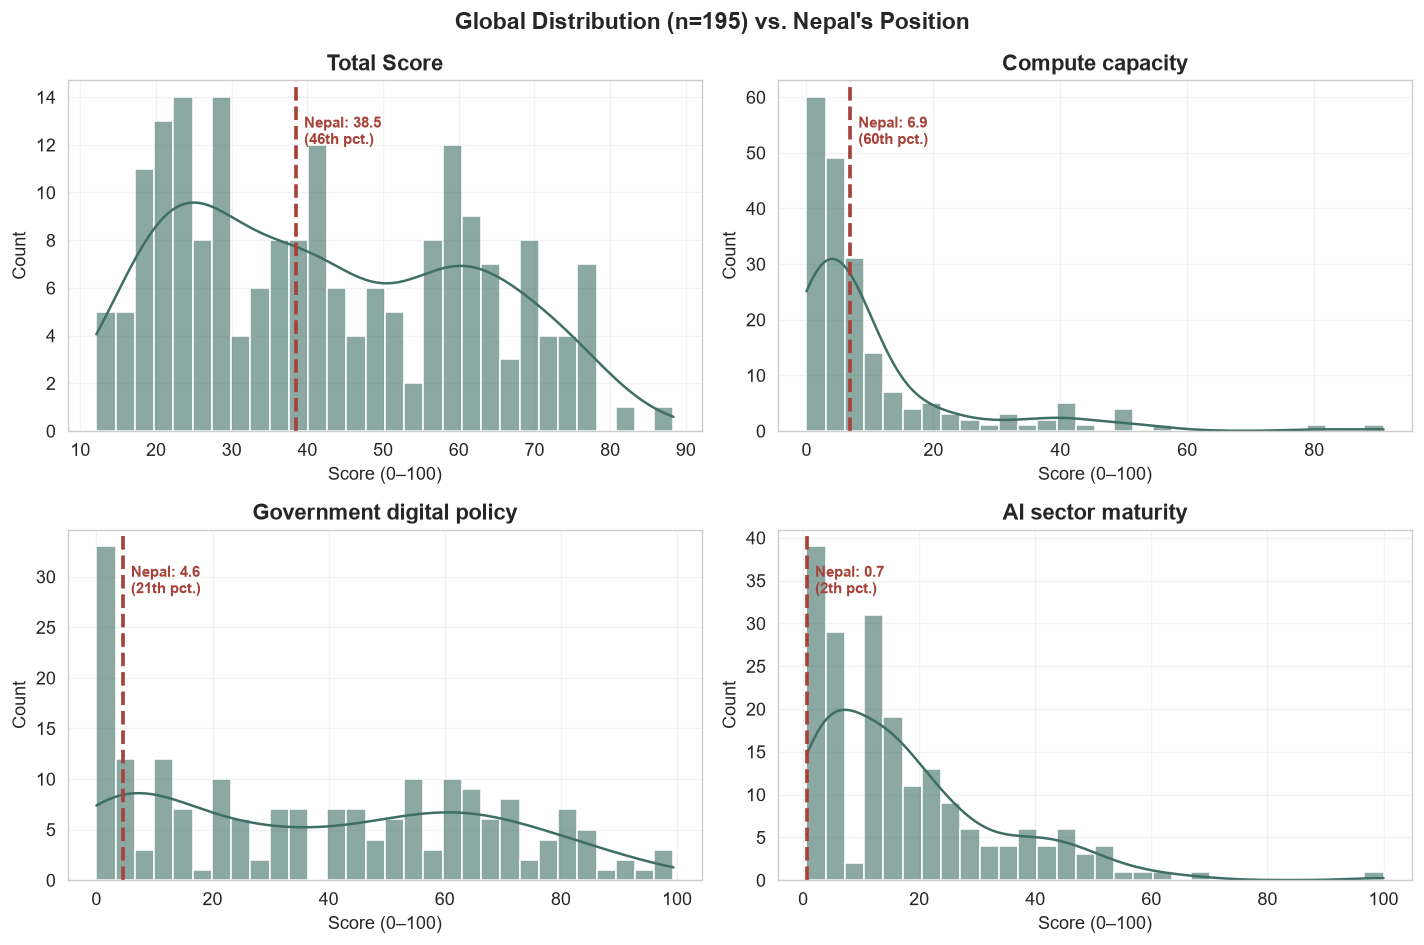

In [15]:
KEY_METRICS = ["Total Score", "Compute capacity", "Government digital policy", "AI sector maturity"]

fig, axes = plt.subplots(2, 2, figsize=(12, 8))
for ax, metric in zip(axes.flat, KEY_METRICS):
    vals = df[metric].dropna()
    sns.histplot(vals, bins=30, color="#3E6E64", alpha=0.6, ax=ax, kde=True)
    nepal_val = nepal_row[metric]
    pct = stats.percentileofscore(vals, nepal_val)
    ax.axvline(nepal_val, color="#A6423A", linewidth=2.2, linestyle="--")
    ax.text(nepal_val, ax.get_ylim()[1] * 0.9, f"  Nepal: {nepal_val:.1f}\n  ({pct:.0f}th pct.)",
            color="#A6423A", fontsize=9, fontweight="bold", va="top")
    ax.set_title(metric)
    ax.set_xlabel("Score (0–100)")

fig.suptitle("Global Distribution (n=195) vs. Nepal's Position", fontsize=14, fontweight="bold")
fig.tight_layout()
fig.savefig(FIG_DIR / "fig3_global_distributions.png", bbox_inches="tight")
plt.show()

## 7. Figure 4 — Radar profile: Nepal vs. Structural Peers

Six-pillar radar chart. Structural peers only (not global top 10 — that comparison 
is not informative on a radar at this scale gap) to keep the chart legible.

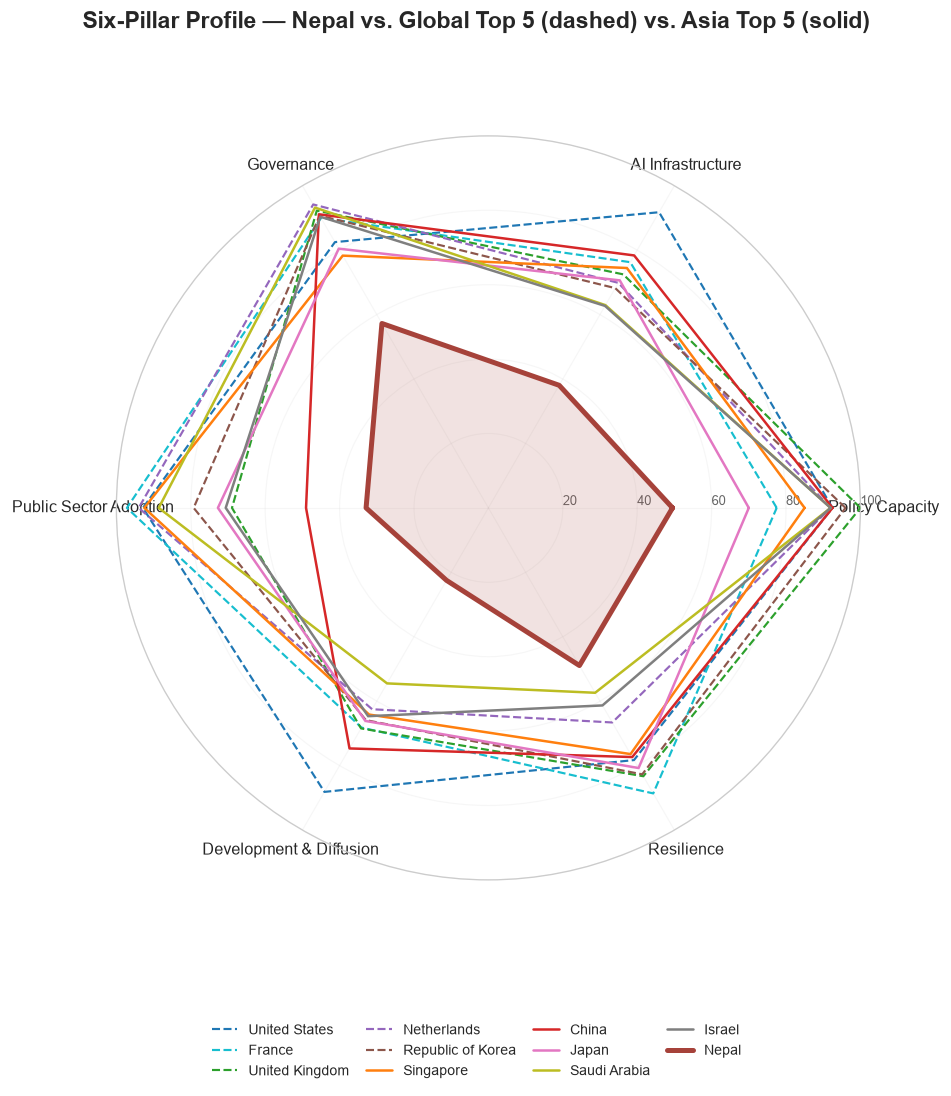

In [23]:
def radar_chart_v2(top_global, top_regional, filename, title):
    labels = PILLARS
    n = len(labels)
    angles = np.linspace(0, 2 * np.pi, n, endpoint=False).tolist()
    angles += angles[:1]

    fig, ax = plt.subplots(figsize=(8, 9), subplot_kw=dict(polar=True))

    # Distinct, easily-told-apart colors (not shades of one hue)
    global_colors = ["#1f77b4", "#17becf", "#2ca02c", "#9467bd", "#8c564b"]
    regional_colors = ["#ff7f0e", "#d62728", "#e377c2", "#bcbd22", "#7f7f7f"]

    def plot_country(country, color, lw, ls, fill):
        row = df[df.Country == country].iloc[0]
        vals = [row[p] for p in labels]
        vals += vals[:1]
        label = country if len(country) < 20 else country.split(",")[0].split(" of ")[0]
        ax.plot(angles, vals, color=color, linewidth=lw, linestyle=ls, label=label, zorder=3)
        if fill:
            ax.fill(angles, vals, color=color, alpha=0.15, zorder=2)

    for c, color in zip(top_global, global_colors):
        plot_country(c, color, 1.3, "--", fill=False)
    for c, color in zip(top_regional, regional_colors):
        plot_country(c, color, 1.5, "-", fill=False)
    plot_country(NEPAL, "#A6423A", 3.0, "-", fill=True)

    ax.set_xticks(angles[:-1])
    ax.set_xticklabels(labels, fontsize=9.5)
    ax.set_ylim(0, 100)
    ax.set_rlabel_position(0)
    ax.tick_params(axis="y", labelsize=8, colors="#666666")
    ax.spines["polar"].set_color("#cccccc")
    ax.grid(color="#dddddd", linewidth=0.7)

    # Title above, legend below — no overlap
    fig.suptitle(title, fontsize=13.5, fontweight="bold", y=0.98)
    handles, leg_labels = ax.get_legend_handles_labels()
    fig.legend(
        handles, leg_labels,
        loc="lower center", bbox_to_anchor=(0.5, -0.02),
        ncol=4, frameon=False, fontsize=8.5, handlelength=1.8, columnspacing=1.2,
    )
    fig.subplots_adjust(top=0.90, bottom=0.14)
    fig.savefig(FIG_DIR / filename, bbox_inches="tight")
    plt.show()

radar_chart_v2(GLOBAL_TOP5, ASIA_TOP5, "fig4_radar_top5_global_regional.png",
               "Six-Pillar Profile — Nepal vs. Global Top 5 (dashed) vs. Asia Top 5 (solid)")

## 8. Regional gap table — the paper's headline finding

Government digital policy across South Asia, with the regional average excluding 
Nepal to show the size of the gap against actual neighbors rather than the world.

South Asia regional average (excl. Nepal), Government digital policy: 35.51
Nepal: 4.56  |  Gap: 30.95 points


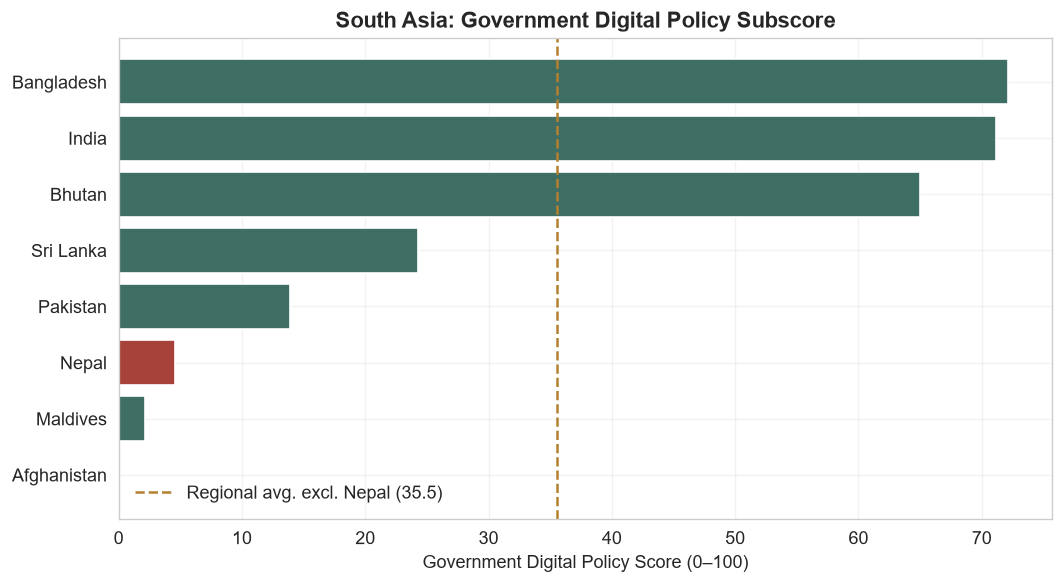

,Country,Ranking,Total Score,Policy commitment,Compute capacity,Government digital policy
0,Bangladesh,75,48.37,75.0,8.31,72.12
1,India,27,66.55,100.0,48.50,71.19
2,Bhutan,101,39.38,0.0,3.29,65.00
3,Sri Lanka,80,45.60,87.5,3.29,24.25
4,Pakistan,81,45.38,62.5,9.99,13.92
5,Nepal,106,38.50,62.5,6.90,4.56
6,Maldives,143,26.39,0.0,3.29,2.12
7,Afghanistan,188,15.72,0.0,3.29,0.00


In [17]:
SOUTH_ASIA = ["Nepal", "India", "Pakistan", "Bangladesh", "Sri Lanka", "Bhutan", "Afghanistan", "Maldives"]
sa_df = df[df.Country.isin(SOUTH_ASIA)][
    ["Country", "Ranking", "Total Score", "Policy commitment", "Compute capacity", "Government digital policy"]
].sort_values("Government digital policy", ascending=False).reset_index(drop=True)

regional_avg_excl_nepal = df[(df.Country.isin(SOUTH_ASIA)) & (df.Country != NEPAL)]["Government digital policy"].mean()
sa_df.to_csv(PROCESSED_DIR / "south_asia_regional_gap.csv", index=False)

print(f"South Asia regional average (excl. Nepal), Government digital policy: {regional_avg_excl_nepal:.2f}")
print(f"Nepal: {nepal_row['Government digital policy']:.2f}  |  Gap: {regional_avg_excl_nepal - nepal_row['Government digital policy']:.2f} points")

fig, ax = plt.subplots(figsize=(9, 5))
colors = ["#A6423A" if c == NEPAL else "#3E6E64" for c in sa_df["Country"]]
bars = ax.barh(sa_df["Country"], sa_df["Government digital policy"], color=colors)
ax.axvline(regional_avg_excl_nepal, color="#B4802F", linestyle="--", linewidth=1.5,
           label=f"Regional avg. excl. Nepal ({regional_avg_excl_nepal:.1f})")
ax.set_xlabel("Government Digital Policy Score (0–100)")
ax.set_title("South Asia: Government Digital Policy Subscore")
ax.legend(frameon=False)
ax.invert_yaxis()
fig.tight_layout()
fig.savefig(FIG_DIR / "fig5_south_asia_gov_digital_policy.png", bbox_inches="tight")
plt.show()

sa_df

In [20]:
def to_markdown_table(dframe: pd.DataFrame) -> str:
    return dframe.to_markdown(index=False)

with open(PROCESSED_DIR / "nepal_scorecard_full_sample.md", "w") as f:
    f.write(to_markdown_table(nepal_scorecard))

with open(PROCESSED_DIR / "south_asia_regional_gap.md", "w") as f:
    f.write(to_markdown_table(sa_df))

print("Tables written to", PROCESSED_DIR)
print("Figures written to", FIG_DIR)
print(list(FIG_DIR.glob("fig*.png")))

Tables written to ..\data\processed
Figures written to ..\outputs\figures
[WindowsPath('../outputs/figures/fig1a_top10_vs_nepal.png'), WindowsPath('../outputs/figures/fig1b_asia_neighbors.png'), WindowsPath('../outputs/figures/fig1c_structural_peers.png'), WindowsPath('../outputs/figures/fig2_subdimension_heatmap.png'), WindowsPath('../outputs/figures/fig3_global_distributions.png'), WindowsPath('../outputs/figures/fig4_radar_structural_peers.png'), WindowsPath('../outputs/figures/fig5_south_asia_gov_digital_policy.png')]
